Part 0: Repository Setup

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cuda


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Part 1.1 — A single neuron is just a line

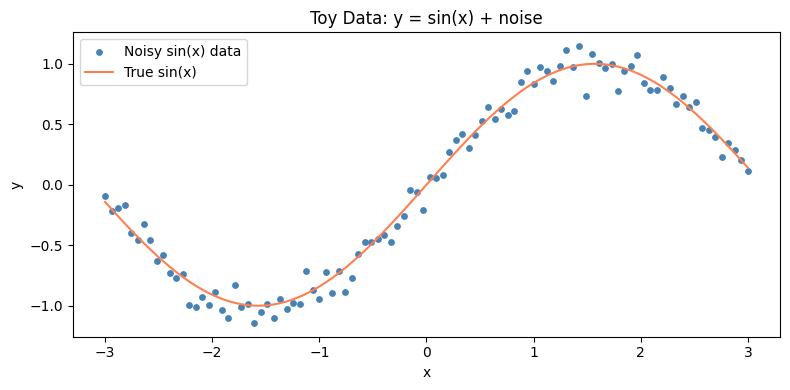

Final w = 0.3390,  b = -0.0104
Final loss = 0.1955


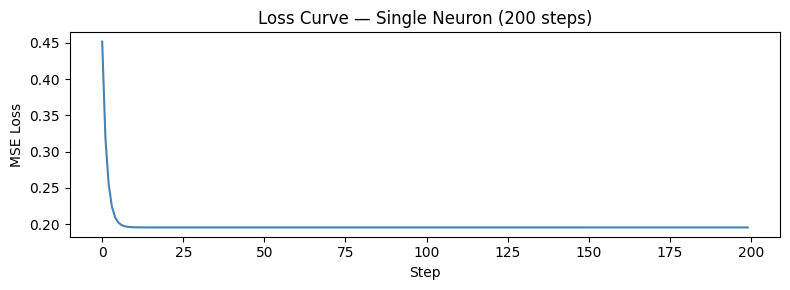

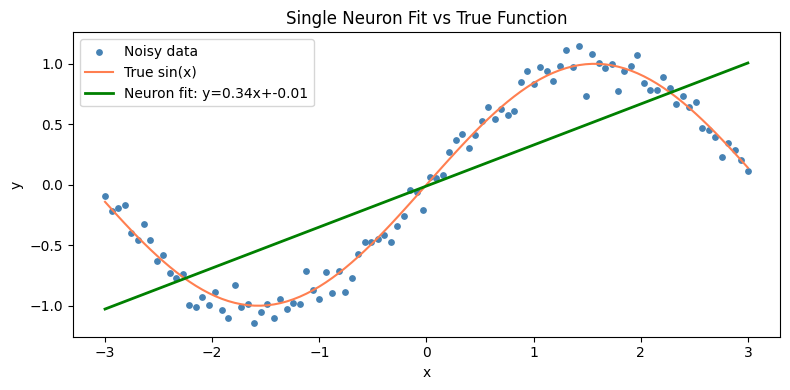

In [2]:
# Generate toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# The plot of the raw data
plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=15, color='steelblue', label='Noisy sin(x) data')
plt.plot(x, np.sin(x), color='coral', linewidth=1.5, label='True sin(x)')
plt.title('Toy Data: y = sin(x) + noise')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

# Initialise w and b to small random values
np.random.seed(RANDOM_STATE)
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

lr     = 0.05
steps  = 200
losses = []

# Gradient descent loop
for step in range(steps):
    # Forward pass: single neuron prediction
    y_hat = w * x + b

    # Loss: Mean Squared Error
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients (derived from MSE loss by chain rule)
    dw = np.mean(2 * (y_hat - y) * x)   # dLoss/dw
    db = np.mean(2 * (y_hat - y))        # dLoss/db

    # Parameter update
    w -= lr * dw
    b -= lr * db

print(f"Final w = {w:.4f},  b = {b:.4f}")
print(f"Final loss = {losses[-1]:.4f}")

# Plot (a): Loss curve
plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue')
plt.title('Loss Curve — Single Neuron (200 steps)')
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.show()

# Plot (b): Data with fitted line
y_final = w * x + b

plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=15, color='steelblue', label='Noisy data')
plt.plot(x, np.sin(x), color='coral', linewidth=1.5, label='True sin(x)')
plt.plot(x, y_final, color='green', linewidth=2, label=f'Neuron fit: y={w:.2f}x+{b:.2f}')
plt.title('Single Neuron Fit vs True Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

**Student Reasoning — The single neuron**

**1. Deriving dLoss/dw:**

Loss = (1/n) * Σ(y_hat - y)²    where y_hat = w*x + b

dLoss/dw = (1/n) * Σ 2(y_hat - y) * x

It matches the code:
dw = np.mean(2 * (y_hat - y) * x)  

**2. Underfitting or overfitting?**

This is underfitting. The loss curve shows the loss dropping quickly
from 0.45 and becoming flattened at 0.20
no matter how many more steps are run. The fit plot confirms this: the
neuron learned y = 0.34x - 0.01, a straight line that cuts through the
middle of the data but completely misses the curve. A single neuron
can never fit a sine wave because it can only compute w*x + b, which
is always a straight line. Sin(x) curves up, peaks, and curves back
down, no straight line can represent that shape no matter of how
long we continued training it.

Part 1.2 — Hidden layers and activations: why depth helps

Final loss WITH tanh: 0.010999


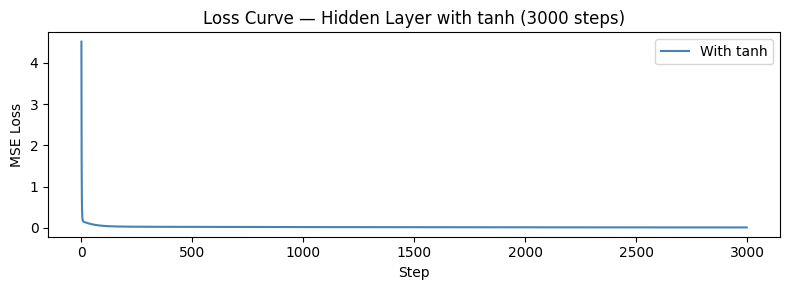

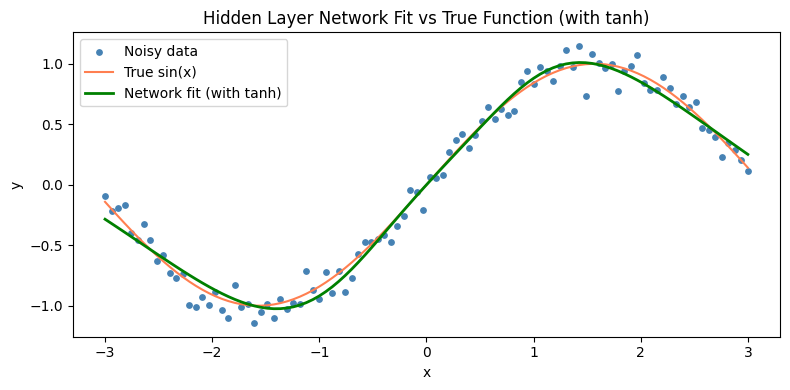

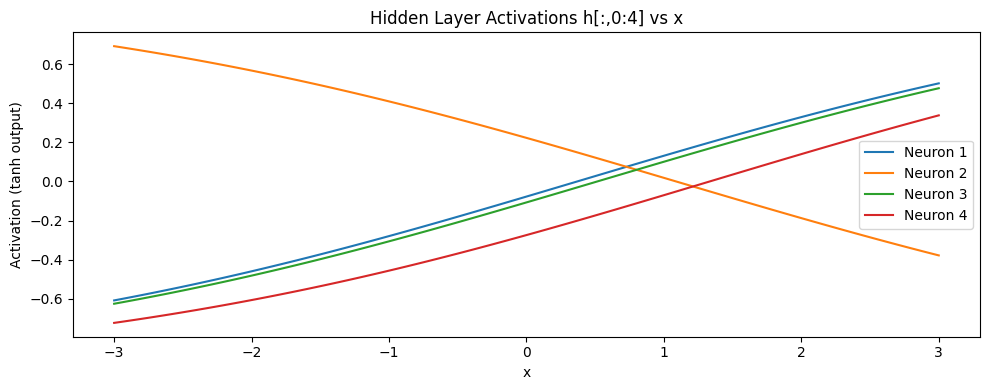

Final loss WITHOUT tanh (linear): 0.195452


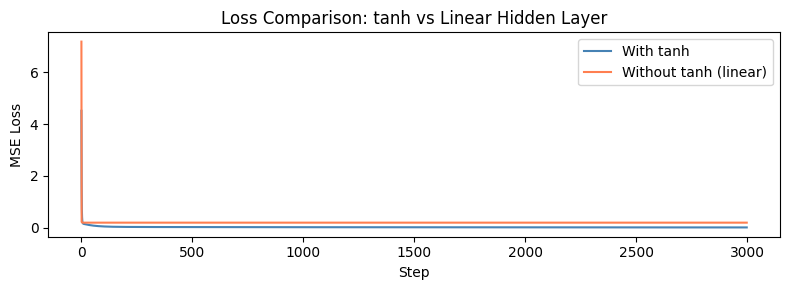

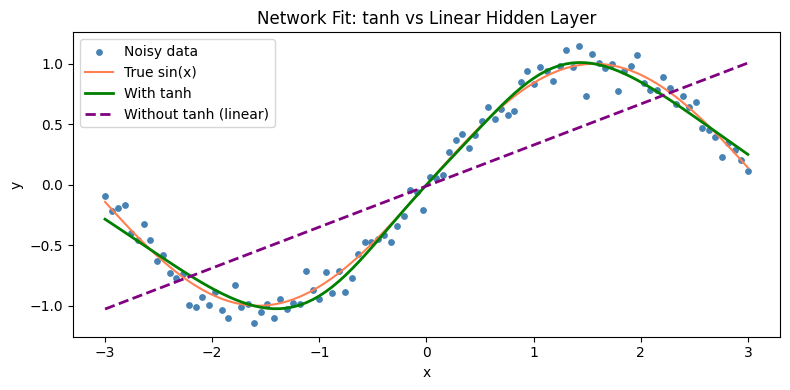

In [ ]:
# Part 1.2: Hidden layers and activations

# Reshape x for matrix operations
x_col = x.reshape(-1, 1)   # shape (100, 1)
y_col = y.reshape(-1, 1)   # shape (100, 1)

# Initialise parameters
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5   # shape (1, 8)
b1 = np.random.randn(8)    * 0.5   # shape (8,)
W2 = np.random.randn(8, 1) * 0.5   # shape (8, 1)
b2 = np.random.randn(1)    * 0.5   # shape (1,)

lr     = 0.05
steps  = 3000
losses = []

# Training loop WITH tanh
for step in range(steps):

    # Forward pass
    z1    = x_col @ W1 + b1          # shape (100, 8)
    h     = np.tanh(z1)              # shape (100, 8)
    y_hat = h @ W2 + b2              # shape (100, 1)
    loss  = np.mean((y_hat - y_col) ** 2)
    losses.append(loss)

    # Backward pass (chain rule layer by layer)
    d_yhat = 2 * (y_hat - y_col) / len(y_col)   # shape (100, 1)
    dW2    = h.T @ d_yhat                         # shape (8, 1)
    db2    = d_yhat.sum(axis=0)                   # shape (1,)
    dh     = d_yhat @ W2.T                        # shape (100, 8)
    dz1    = dh * (1 - np.tanh(z1) ** 2)         # shape (100, 8)
    dW1    = x_col.T @ dz1                        # shape (1, 8)
    db1    = dz1.sum(axis=0)                      # shape (8,)

    # Parameter updates
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

print(f"Final loss WITH tanh: {losses[-1]:.6f}")

# Plot (a): Loss curve WITH tanh
plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue', label='With tanh')
plt.title('Loss Curve — Hidden Layer with tanh (3000 steps)')
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Plot (b): Final fit WITH tanh
plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=15, color='steelblue', label='Noisy data')
plt.plot(x, np.sin(x), color='coral', linewidth=1.5, label='True sin(x)')
plt.plot(x, y_hat.flatten(), color='green', linewidth=2, label='Network fit (with tanh)')
plt.title('Hidden Layer Network Fit vs True Function (with tanh)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

# Plot a few columns of h to show what each neuron learned
plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(x, h[:, i], label=f'Neuron {i+1}')
plt.title('Hidden Layer Activations h[:,0:4] vs x')
plt.xlabel('x')
plt.ylabel('Activation (tanh output)')
plt.legend()
plt.tight_layout()
plt.show()

# Re-run WITHOUT tanh (h = z1, purely linear)
np.random.seed(RANDOM_STATE)
W1_lin = np.random.randn(1, 8) * 0.5
b1_lin = np.random.randn(8)    * 0.5
W2_lin = np.random.randn(8, 1) * 0.5
b2_lin = np.random.randn(1)    * 0.5

losses_linear = []

for step in range(steps):

    # Forward pass — NO tanh, h = z1
    z1_lin    = x_col @ W1_lin + b1_lin
    h_lin     = z1_lin                           # linear activation
    y_hat_lin = h_lin @ W2_lin + b2_lin
    loss_lin  = np.mean((y_hat_lin - y_col) ** 2)
    losses_linear.append(loss_lin)

    # Backward pass
    d_yhat_lin = 2 * (y_hat_lin - y_col) / len(y_col)
    dW2_lin    = h_lin.T @ d_yhat_lin
    db2_lin    = d_yhat_lin.sum(axis=0)
    dh_lin     = d_yhat_lin @ W2_lin.T
    dz1_lin    = dh_lin                          # derivative of linear = 1
    dW1_lin    = x_col.T @ dz1_lin
    db1_lin    = dz1_lin.sum(axis=0)

    W2_lin -= lr * dW2_lin
    b2_lin -= lr * db2_lin
    W1_lin -= lr * dW1_lin
    b1_lin -= lr * db1_lin

print(f"Final loss WITHOUT tanh (linear): {losses_linear[-1]:.6f}")

# Plot both loss curves together
plt.figure(figsize=(8, 3))
plt.plot(losses,        color='steelblue', label='With tanh')
plt.plot(losses_linear, color='coral',     label='Without tanh (linear)')
plt.title('Loss Comparison: tanh vs Linear Hidden Layer')
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Final fit WITHOUT tanh
plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=15, color='steelblue', label='Noisy data')
plt.plot(x, np.sin(x),          color='coral',     linewidth=1.5, label='True sin(x)')
plt.plot(x, y_hat.flatten(),    color='green',     linewidth=2,   label='With tanh')
plt.plot(x, y_hat_lin.flatten(), color='purple',   linewidth=2,   linestyle='--', label='Without tanh (linear)')
plt.title('Network Fit: tanh vs Linear Hidden Layer')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

**Student Reasoning — Depth and activations**

**1. Why a stack of linear layers collapses into one linear layer:**

Without tanh, each layer computes: output = input * W + b.
If we stack two linear layers:
  Layer 1: z1 = x * W1 + b1
  Layer 2: y_hat = z1 * W2 + b2
           y_hat = (x * W1 + b1) * W2 + b2
           y_hat = x * (W1 * W2) + (b1 * W2 + b2)

This is just x * W_combined + b_combined, a single linear function.
No matter how many layers you stack, the result is always just w*x + b.
The loss comparison plot confirms this, without tanh, the final loss
is 0.1955, identical to the single neuron in Part 1.1. The dashed
purple line in the fit plot is just a straight line, the same as
Part 1.1's green line.

**2. What the 8 hidden neurons did:**

The activation plot shows each neuron learned a different S-shaped
tanh curve with a different slope and crossing point. Neuron 2 (orange)
starts high and decreases, while Neurons 1, 3, and 4 start low and
increase at slightly different rates. The output layer combined these
8 different curved shapes with learned weights to produce the final
sine-shaped prediction. This is why the network with tanh achieved
a final loss of 0.011, nearly 18 times better than the linear
version (0.195). The hidden neurons act as building blocks, each
contributing a different curved piece that together approximate sin(x).

**3. What is backpropagation?**

Backpropagation is the process of computing how much each weight
contributed to the final loss by applying the chain rule backwards
through every layer, so each weight knows exactly how to update
itself to reduce the loss.

Part 1.3 — The learning rate: too cold, too hot, just right

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_473/912050589.py:21: RuntimeWarning: overflow encountered in square
  loss  = np.mean((y_hat - y_col) ** 2)
/tmp/ipykernel_473/912050589.py:28: RuntimeWarning: overflow encountered in matmul
  dh     = d_yhat @ W2.T
/tmp/ipykernel_473/912050589.py:29: RuntimeWarning: invalid value encountered in multiply
  dz1    = dh * (1 - np.tanh(z1) ** 2)


Final loss (lr=0.001): 0.071819
Final loss (lr=0.05):  0.010999
Final loss (lr=1.0):   nan


/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


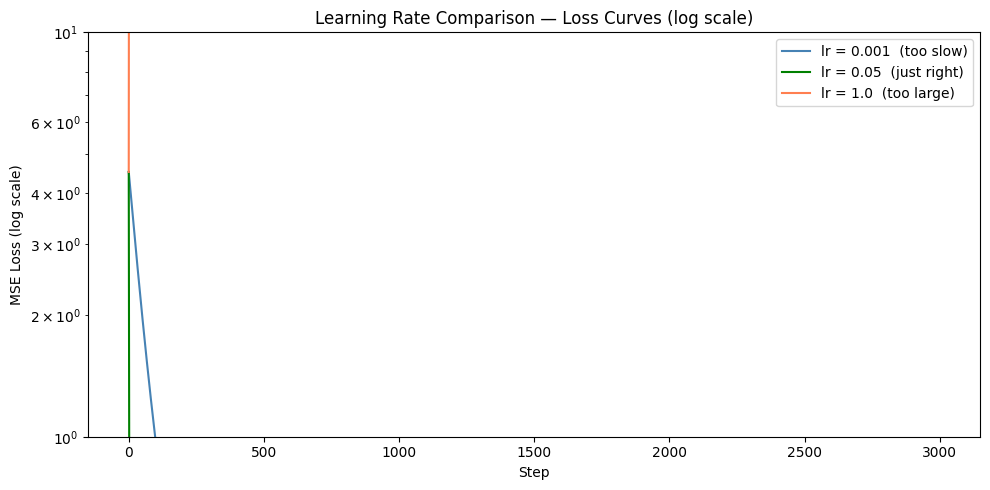

In [ ]:
# Part 1.3: The learning rate — too cold, too hot, just right

def train_toy(lr, steps=3000):
    """Train the Part 1.2 network with a given learning rate.
    Resets the seed before every run for a fair comparison."""

    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8)    * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1)    * 0.5

    losses = []

    for step in range(steps):

        # Forward pass
        z1    = x_col @ W1 + b1
        h     = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss  = np.mean((y_hat - y_col) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2    = h.T @ d_yhat
        db2    = d_yhat.sum(axis=0)
        dh     = d_yhat @ W2.T
        dz1    = dh * (1 - np.tanh(z1) ** 2)
        dW1    = x_col.T @ dz1
        db1    = dz1.sum(axis=0)

        # Parameter update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    return losses

# Run with three learning rates
lr_slow   = 0.001
lr_good   = 0.05
lr_large  = 1.0

losses_slow  = train_toy(lr=lr_slow)
losses_good  = train_toy(lr=lr_good)
losses_large = train_toy(lr=lr_large)

print(f"Final loss (lr=0.001): {losses_slow[-1]:.6f}")
print(f"Final loss (lr=0.05):  {losses_good[-1]:.6f}")
print(f"Final loss (lr=1.0):   {losses_large[-1]:.6f}")

# Plot all three on the same axes (log scale on y)
plt.figure(figsize=(10, 5))
plt.plot(losses_slow,  color='steelblue', label=f'lr = {lr_slow}  (too slow)')
plt.plot(losses_good,  color='green',     label=f'lr = {lr_good}  (just right)')
plt.plot(losses_large, color='coral',     label=f'lr = {lr_large}  (too large)')
plt.yscale('log')
plt.title('Learning Rate Comparison — Loss Curves (log scale)')
plt.xlabel('Step')
plt.ylabel('MSE Loss (log scale)')
plt.legend()
plt.tight_layout()
plt.show()

**Student Reasoning - Learning rate**

**lr = 0.001 (too slow - blue):**
The loss starts dropping but is still at 0.072 after 3000 steps,
which is much worse than lr=0.05 achieved. The curve is descending
so slowly that 3000 steps are not enough to reach a good solution.
With more steps it would eventually get there, but it is far too
inefficient in practice.

**lr = 0.05 (just right - green):**
The loss drops steeply in the first ~100 steps and flattens out
near 0.011, the best result of all three. This matches what we
saw in Part 1.2. The step size is small enough to follow the slope
of the loss surface smoothly without overshooting.

**lr = 1.0 (too large - orange):**
The loss immediately explodes to NaN (not a number), confirmed by
the overflow warnings. The curve shoots up off the chart in the
very first step and never recovers. Final loss = nan.

**Why a too-large learning rate explodes instead of just learning faster:**
Gradient descent moves in the direction of the negative gradient by
a step of size lr * gradient. When lr is too large, each update
overshoots the minimum, instead of landing near the bottom of the
loss curve, the weights jump past it to a worse position on the
other side. The gradient there is even larger, so the next step
overshoots even further. This keeps amplifying until the values
overflow to infinity and then NaN. A large lr does not speed up
learning, it destroys it by making updates too aggressive to
ever settle at a minimum.